In [110]:
import pandas as pd 
pd.options.mode.chained_assignment = None  # default='warn'
import sys
import numpy as np
import os
import glob
import matplotlib.pyplot as plt 
import scipy.stats

from config import home_path, llm_review_path, supp_table_path

sys.path.insert(1, home_path) 
from common_functions import (
    my_colors, 
    format_p, 
    get_pfam_info, 
    mean_confidence_interval, 
    sort_dict_by_key, 
    sort_dict_by_value,
    three_letter_to_one_letter,
    entropy,
    smart_glob
)

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns 
import copy 
from sklearn import metrics
import time
import random
random.seed(0)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

In [5]:


def extract_coding_info_from_name(name_str, return_ref = True, return_pos = False, return_alt = False):
    try:
        pieces = name_str.split("(p.")
        needed_piece = pieces[1]
        ref_aa = needed_piece[:3]
        piece_2 = needed_piece.split(")")[0]
        if piece_2[-1] == "=":
            alt_aa = ref_aa
            aa_pos = int(piece_2[3:-1])
        else:
            alt_aa = piece_2[-3:]
            aa_pos = int(piece_2[3:-3])
        if return_alt:
            return alt_aa
        elif return_pos:
            return aa_pos
        else:
            return ref_aa
    except:
        print("error", name_str)
        return None
    

# assumption is scores_1 is lower (more pathogenic)

def get_argmax_accuracy_point(scores_1, scores_2):
    maximum_val = max(np.max(scores_1), np.max(scores_2))
    minimum_val = min(np.min(scores_1), np.min(scores_2))
    argmax = None 
    max_accuracy = float("-inf")
    argmax_conf = []
    
    for cutoff in np.arange(minimum_val, maximum_val, 0.01):
        true_positives = np.sum(scores_2 > cutoff)
        false_negatives = np.sum(scores_2 <= cutoff)
        
        true_negatives = np.sum(scores_1 <= cutoff)
        false_postitives =  np.sum(scores_1 > cutoff)
        
        total_obs = true_positives + false_negatives + true_negatives + false_postitives
        accuracy = (true_positives + true_negatives) / total_obs
        
        if accuracy > max_accuracy:
            max_accuracy = accuracy
            argmax = cutoff
            argmax_conf = [[true_positives, false_postitives], [false_negatives, true_negatives]]
    
    return max_accuracy, argmax, argmax_conf

def p_val_to_stars(p):
    if p <= 0.001:
        return "***"
    if p <= 0.01:
        return "**"
    if p <= 0.05:
        return "*"
    return "ns"


def save_figure(
    fig, 
    name, 
    root_path = llm_review_path + "high_res_figures/length_figure/clinvar_misclassification/", 
    save_svg = True,
    bbox_inches = "tight"
):
    fig.savefig(root_path + name + ".png", bbox_inches = "tight")
    if save_svg:
        fig.savefig(root_path + name + ".svg", format="svg", dpi = 1200, bbox_inches = bbox_inches)

In [98]:
human_info = pd.read_csv(llm_review_path + "data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")

entry_to_uniport_id = dict(zip(human_info["Entry Name"].values,human_info["Entry"].values))
gene_to_entry = {}
for index, row in human_info.iterrows():
    gene_vals = row["Gene Names"]
    if pd.isna(gene_vals):
        gene_vals = [entry_name.replace("_HUMAN", "")]
    else:
        gene_vals = row["Gene Names"].split(" ")
        entry_name = row["Entry Name"]
    for g in gene_vals:
        gene_to_entry[g.upper()] = entry_name


model_to_display = {
    "esm_1_43M" : "ESM-1 (43M)",
    "esm_1_85M" : "ESM-1 (85M)",
    "esm_1b" : "ESM-1b (650M)",
    "esm_1v" : "ESM-1v (650M)",
    "esm_1_UR50" : "ESM-1 UR50 (670M)",
    "esm_1_UR50D" : "ESM-1 UR50D (670M)",
    "esm_1_UR100" : "ESM-1 UR100 (670M)",
    "protbert" : "ProtBERT",
    "esm_2_15B" : "ESM-2 (15B)",
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" : "ESM-2 (35M)",
    "esm_2_150M" : "ESM-2 (150M)",
    "esm_2_650M" : "ESM-2 (650M)",
    "esm_2" : "ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)"
}

In [101]:

density_fig_large, axes_density = plt.subplots(5, 3, figsize = (18, 15))
density_fig_large.subplots_adjust(hspace = 0.7, wspace = 0.4)
axes_density = axes_density.ravel()


boxplot_fig_large, axes_boxplot = plt.subplots(4,4, figsize = (15, 18))
boxplot_fig_large.subplots_adjust(hspace = 0.5, wspace = 0.4)
axes_boxplot = axes_boxplot.ravel()

random_state = 2025

model_to_misclass_info = {}

for ax_i, model in enumerate(model_to_display.keys()):

    clinvar_short_annotations = pd.read_csv(f"{home_path}clinvar/nlp_review_misclassification/short_protein_clinvar_scores/{model}.csv", index_col = 0 )

    valid_short = set()

    for k, sub_df in clinvar_short_annotations.groupby("entry"):
        n_plp = sub_df.loc[sub_df["classification"] == "PLP"]
        n_blb = sub_df.loc[sub_df["classification"] == "BLB"]
        n_vus = sub_df.loc[sub_df["classification"] == "VUS"]
        if len(n_blb) >= 5 and len(n_plp) >= 5:
            chosen_blb = n_blb.sample(frac = 1, random_state = random_state).head(5)
            chosen_plp = n_plp.sample(frac = 1, random_state = random_state).head(5)
            chosen_vus = n_vus.sample(frac = 1, random_state = random_state).head(5)

            for i in chosen_blb["full_name"].values:
                valid_short.add(i)
            for i in chosen_plp["full_name"].values:
                valid_short.add(i)
            for i in chosen_vus["full_name"].values:
                valid_short.add(i)


    short_protein_path = home_path + "clinvar/nlp_review_misclassification/short_protein_clinvar_scores/"
    short_protein_score_df = pd.read_csv(short_protein_path + model + ".csv", index_col = 0 )
    short_protein_score_df = short_protein_score_df.loc[short_protein_score_df["full_name"].isin(valid_short)]

    clinvar_long = pd.read_csv(home_path + "clinvar/nlp_review_misclassification/clinvar_annotations_long_genes.csv")
    clinvar_long["full_name"] = clinvar_long["entry"] + "_" + clinvar_long["name"] 
    clinvar_long_variant_to_annotation = dict(zip(clinvar_long["full_name"].values, clinvar_long["classification"].values))


    valid_long = set()
    limit_certain_long = True
    
    

    for k, sub_df in clinvar_long.groupby("entry"):
        n_plp = sub_df.loc[sub_df["classification"] == "PLP"]
        n_blb = sub_df.loc[sub_df["classification"] == "BLB"]
        n_vus = sub_df.loc[sub_df["classification"] == "VUS"]
        
        if len(n_blb) >= 5 and len(n_plp) >= 5:
            chosen_blb = n_blb.sample(frac = 1, random_state = random_state).head(5)
            chosen_plp = n_plp.sample(frac = 1, random_state = random_state).head(5)
            chosen_vus = n_vus.sample(frac = 1, random_state = random_state).head(5)

            for i in chosen_blb["full_name"].values:
                valid_long.add(i)
            for i in chosen_plp["full_name"].values:
                valid_long.add(i)

            for i in chosen_vus["full_name"].values:
                valid_long.add(i)

    long_protein_path = home_path + "clinvar/nlp_review_misclassification/combined_tiled_scores_all_genes/" 
    long_protein_score_df = pd.read_csv(long_protein_path + f"combined_scores_{model}_all_values_clinvar_only.csv.gz")
    long_protein_score_df["full_name"] = long_protein_score_df["gene_name"] + "_" + long_protein_score_df["name"]

    all_dual_tiled_variants = long_protein_score_df.loc[long_protein_score_df["num_tiles"] > 1]
    dual_tiled_set = set(all_dual_tiled_variants["full_name"].values)
    long_protein_score_df = long_protein_score_df.loc[long_protein_score_df["full_name"].isin(valid_long)]
    print(len(long_protein_score_df), len(short_protein_score_df))

    # boxplot 

    ax = axes_boxplot[ax_i]
    
    

    blb_long_scores = long_protein_score_df.loc[long_protein_score_df["clinvar_annotation"] == "BLB"]["weighted_score"].values
    vus_long_scores = long_protein_score_df.loc[long_protein_score_df["clinvar_annotation"] == "VUS"]["weighted_score"].values
    plp_long_scores = long_protein_score_df.loc[long_protein_score_df["clinvar_annotation"] == "PLP"]["weighted_score"].values

    blb_short_scores = short_protein_score_df.loc[short_protein_score_df["classification"] == "BLB"]["score"].values
    vus_short_scores = short_protein_score_df.loc[short_protein_score_df["classification"] == "VUS"]["score"].values
    plp_short_scores = short_protein_score_df.loc[short_protein_score_df["classification"] == "PLP"]["score"].values

    data = [blb_long_scores, blb_short_scores, vus_long_scores, vus_short_scores, plp_long_scores, plp_short_scores]
    
    print("boxplot info varaints", len(blb_long_scores), len(blb_short_scores), len(vus_long_scores), len(vus_short_scores), len(plp_long_scores), len(plp_short_scores))
    print("boxplot info genes", len(set(long_protein_score_df["gene_name"])), len(set(short_protein_score_df["entry"])))
    
    my_pal = {
        0 : "darkseagreen", 
        1 : "darkseagreen", 
        2 : "#c9c9c9", 
        3 : "#c9c9c9", 
        4 : "salmon", 
        5 : "salmon"
    }


    ax = sns.boxplot(
        data,
        palette = my_pal,
        showfliers = False,
        boxprops=dict(linewidth=2, edgecolor='black', zorder = 100),
        medianprops=dict(linewidth=2, color='black', zorder = 100),
        whiskerprops=dict(linewidth=2, color='black', zorder = 100),
        capprops = dict(linewidth=2, color='black', zorder = 100),
        ax = ax
    )


    patches = [patch for patch in ax.patches if type(patch) == mpatches.PathPatch]
   
    hatch_list = ["//", "", "//", "", "//", ""]
    for patch, hatch in zip(patches, hatch_list):
        patch.set_hatch(hatch)

    hatch_colors = ["white", "gray", "white", "gray", "white", "gray"]
    for i, patch in enumerate(ax.patches):
        patch._hatch_color = mcolors.to_rgba(hatch_colors[i])


    ax.set_yticks([-30, -20, -10, 0, 10])
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
    
    for y_val in ax.get_yticks():
        ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(
        [
            "Long\nB/LB",
            "Short\nB/LB",
    #         "",
            "Long\nVUS",
            "Short\nVUS",
    #         "",
            "Long\nP/LP",
            "Short\nP/LP",
        ],
        fontsize = 8,
        fontweight = "bold"
    )

    rect1 = mpatches.Rectangle(((1/6)-0.08, -0.15), 1/6, 0.002,  transform = ax.transAxes, clip_on = False, color = "black")
    rect2 = mpatches.Rectangle((3/6-0.08, -0.15), 1/6, 0.002, transform = ax.transAxes,clip_on = False, color = "black")
    rect3 = mpatches.Rectangle((5/6-0.08, -0.15), 1/6, 0.002,transform = ax.transAxes, clip_on = False, color = "black")
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    ax.add_patch(rect3)

    st, p = scipy.stats.mannwhitneyu(blb_long_scores, blb_short_scores, alternative = "greater")
    p_str = format_p(p)
    p_stars = p_val_to_stars(p)
    ax.text(1/6,  -0.2 if p_stars == "ns" else -0.22, p_stars , transform = ax.transAxes, horizontalalignment = "center", fontsize = 9 if p_stars == "ns" else 12, fontweight = "bold")

    st, p = scipy.stats.mannwhitneyu(vus_long_scores, vus_short_scores, alternative = "greater")
    p_str = format_p(p)

    p_stars = p_val_to_stars(p)
    ax.text(3/6,  -0.2 if p_stars == "ns" else -0.22, p_stars, transform = ax.transAxes, horizontalalignment = "center", fontsize = 9 if p_stars == "ns" else 12, fontweight = "bold")
    
    
    st, p = scipy.stats.mannwhitneyu(plp_long_scores, plp_short_scores, alternative = "greater")
    p_stars = p_val_to_stars(p)
    ax.text(5/6,  -0.2 if p_stars == "ns" else -0.22, p_stars, transform = ax.transAxes, horizontalalignment = "center", fontsize = 9 if p_stars == "ns" else 12, fontweight = "bold")

    ax.set_ylabel("VEP Score", fontsize = 11, fontweight = "bold")
    ax.set_title(model_to_display[model], fontsize = 13, fontweight = "bold")
    ## creating train and test dfs 
    ###############################################
    ###############################################

    print(model)
    
    all_genes = list(long_protein_score_df["gene_name"].values) + list(short_protein_score_df["entry"].values)
    all_genes = pd.DataFrame(all_genes, columns = ["gene"])
    all_genes = all_genes.drop_duplicates(subset= "gene")
    all_genes = all_genes.sample(frac = 1, random_state = random_state)
        
    train_pct = 0.5
    train_genes = all_genes.head(int(train_pct * len(all_genes)))["gene"].values
    
    print("gene_counts", len(train_genes), len(all_genes) - len(train_genes))
   

    train_short = short_protein_score_df.loc[short_protein_score_df["entry"].isin(train_genes)]
    train_long = long_protein_score_df.loc[long_protein_score_df["gene_name"].isin(train_genes)]

    test_short = short_protein_score_df.loc[~short_protein_score_df["entry"].isin(train_genes)]
    test_long = long_protein_score_df.loc[~long_protein_score_df["gene_name"].isin(train_genes)]

    train_blb = list(train_short.loc[train_short["classification"] == "BLB"]["score"]) + list(train_long.loc[train_long["clinvar_annotation"] == "BLB"]["weighted_score"])
    train_plp = list(train_short.loc[train_short["classification"] == "PLP"]["score"]) + list(train_long.loc[train_long["clinvar_annotation"] == "PLP"]["weighted_score"])
    
    print("Trianing total", len(train_blb) + len(train_plp))
    
    print("gene_counts train long", len(set(train_long["gene_name"])), "gene counts train short", len(set(train_short["entry"])))
    print("gene_counts test long", len(set(test_long["gene_name"])), "gene counts test short", len(set(test_short["entry"])))
    
    print("variant counts train", len(train_blb), len(train_plp))
    acc, argmax_acc, conf_mat = get_argmax_accuracy_point(train_plp, train_blb)
    training_conf_mat = copy.deepcopy(conf_mat)
    ############### plotting kdeplots 

#     fig2, ax = plt.subplots(figsize = (6,2.5))
    
    ax = axes_density[ax_i]


    sns.kdeplot(train_plp, ax = ax, fill = True, color = "salmon", label = "P/LP")
    sns.kdeplot(train_blb, ax = ax, fill = True, color = "darkseagreen", label = "B/LB")

    
    
    ax.set_xlabel("VEP Score", fontsize = 11, fontweight = "bold")
    ax.set_title(model_to_display[model], fontsize = 12, fontweight = "bold")
    ax.set_ylabel("Density", fontsize = 11, fontweight = "bold")
    ax.set_yticks(ax.get_yticks())
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
    
    ax.axvline(x = argmax_acc, linestyle = "--", color = "black", alpha = 0.4,label = "$\phi_m$")

#     ax.legend(loc = "upper right")

    acc_str = str(round(acc * 100, 2)) + "%"
    
    if model == "esm_2_15B":
        ax.text(0.61, 0.15, "Acc = " + acc_str, transform = ax.transAxes, fontweight = "bold")
    else:
        ax.text(0.03, 0.9, "Acc = " + acc_str, transform = ax.transAxes, fontweight = "bold")



    ###############

    miscalss_rate_plp = conf_mat[1][0] / (conf_mat[1][0] + conf_mat[0][0])
    miscalss_rate_blb = conf_mat[0][1] / (conf_mat[0][1] + conf_mat[1][1])

    print("train miscalss rate PLP ", miscalss_rate_plp)
    print("train miscalss rate BLB ", miscalss_rate_blb)
    ######
    
    test_short_plp = test_short.loc[test_short["classification"] == "PLP"]["score"].values
    test_long_plp = test_long.loc[test_long["clinvar_annotation"] == "PLP"]["weighted_score"].values
    
    test_short_blb = test_short.loc[test_short["classification"] == "BLB"]["score"].values
    test_long_blb = test_long.loc[test_long["clinvar_annotation"] == "BLB"]["weighted_score"].values
    print("varaint_counts test", len(test_short_plp) + len(test_long_plp), len(test_short_blb) + len(test_long_blb),len(test_short_plp) + len(test_long_plp) + len(test_short_blb) + len(test_long_blb) )
    
    #############  predictions for PLP 
    long_protein_plp_predicted_plp = np.sum(test_long_plp <= argmax_acc)
    long_protein_plp_predicted_blb = np.sum(test_long_plp > argmax_acc)

    short_protein_plp_predicted_plp = np.sum(test_short_plp <= argmax_acc)
    short_protein_plp_predicted_blb = np.sum(test_short_plp > argmax_acc)


    print("PLP miscalss rate long" , long_protein_plp_predicted_blb / len(test_long_plp))
    print("PLP miscalss rate short", short_protein_plp_predicted_blb / len(test_short_plp))

    table_plp = [
        [long_protein_plp_predicted_plp, long_protein_plp_predicted_blb],
        [short_protein_plp_predicted_plp, short_protein_plp_predicted_blb]
    ]

    chi_p_plp = scipy.stats.chi2_contingency(table_plp)[1]

    fc_plp = (table_plp[0][1] / np.sum(table_plp[0])) / (table_plp[1][1] / np.sum(table_plp[1]))

    print("chi sq p PLP", chi_p_plp)


    #############  predictions for BLB 
    long_protein_blb_predicted_plp = np.sum(test_long_blb <= argmax_acc)
    long_protein_blb_predicted_blb = np.sum(test_long_blb > argmax_acc)

    short_protein_blb_predicted_plp = np.sum(test_short_blb <= argmax_acc)
    short_protein_blb_predicted_blb = np.sum(test_short_blb > argmax_acc)


    print("BLB miscalss rate long" , long_protein_blb_predicted_plp / len(test_long_blb))
    print("BLB miscalss rate short", short_protein_blb_predicted_plp / len(test_short_blb))

    table_blb = [
        [long_protein_blb_predicted_blb, long_protein_blb_predicted_plp],
        [short_protein_blb_predicted_blb, short_protein_blb_predicted_plp]
    ]

    chi_p_blb = scipy.stats.chi2_contingency(table_blb)[1]

    fc_blb = (table_blb[0][1] / np.sum(table_blb[0])) / (table_blb[1][1] / np.sum(table_blb[1]))

    print("chi sq p BLB", chi_p_blb)

    full_table = np.asarray(table_blb) + np.asarray(table_plp)

    chi_2_combined = scipy.stats.chi2_contingency(full_table)[1]

    fc_full = (full_table[0][1] / np.sum(full_table[0])) / (full_table[1][1] / np.sum(full_table[1]))

    misclass_info = {
        "accuracy_train" : acc,
        "argmax_for_density_fig" : argmax_acc,
        "PLP_table" : table_plp,
        "BLB_table" : table_blb,
        "combined_table" : full_table,
        "chi_2_PLP" : chi_p_plp,
        "chi_2_BLB" : chi_p_blb,
        "chi_2_combined" : chi_2_combined,
        "PLP_misclass_rate_long" : long_protein_plp_predicted_blb / len(test_long_plp),
        "PLP_misclass_rate_short" : short_protein_plp_predicted_blb / len(test_short_plp),
        "BLB_misclass_rate_long" : long_protein_blb_predicted_plp / len(test_long_blb),
        "BLB_misclass_rate_short" : short_protein_blb_predicted_plp / len(test_short_blb),
        "fc_BLB" : fc_blb,
        "fc_PLP" : fc_plp,
        "fc_full" : fc_full,
        "train_short_df" : train_short,
        "train_long_df" : train_long,
        "test_short_df" : test_short,
        "test_long_df" : test_long,
        "training_PLP_misclass_rate" : miscalss_rate_plp,
        "training_BLB_misclass_rate" : miscalss_rate_blb,
        "training_conf_mat" : training_conf_mat,
        
    }
    model_to_misclass_info[model] = misclass_info
    
plt.close('all')

5505 9930
boxplot info varaints 1835 3310 1835 3310 1835 3310
boxplot info genes 367 662
esm_1_43M
gene_counts 514 515
Trianing total 5140
gene_counts train long 183 gene counts train short 331
gene_counts test long 184 gene counts test short 331
variant counts train 2570 2570
train miscalss rate PLP  0.11712062256809339
train miscalss rate BLB  0.46575875486381324
varaint_counts test 2575 2575 5150
PLP miscalss rate long 0.48695652173913045
PLP miscalss rate short 0.46042296072507555
chi sq p PLP 0.2107296128694958
BLB miscalss rate long 0.12282608695652174
BLB miscalss rate short 0.1256797583081571
chi sq p BLB 0.8824849594196476
5505 9930
boxplot info varaints 1835 3310 1835 3310 1835 3310
boxplot info genes 367 662
esm_1_85M
gene_counts 514 515
Trianing total 5140
gene_counts train long 183 gene counts train short 331
gene_counts test long 184 gene counts test short 331
variant counts train 2570 2570
train miscalss rate PLP  0.15330739299610896
train miscalss rate BLB  0.3163424124

5505 9930
boxplot info varaints 1835 3310 1835 3310 1835 3310
boxplot info genes 367 662
esm_2
gene_counts 514 515
Trianing total 5140
gene_counts train long 183 gene counts train short 331
gene_counts test long 184 gene counts test short 331
variant counts train 2570 2570
train miscalss rate PLP  0.20505836575875486
train miscalss rate BLB  0.17626459143968873
varaint_counts test 2575 2575 5150
PLP miscalss rate long 0.20652173913043478
PLP miscalss rate short 0.1311178247734139
chi sq p PLP 6.69749620199158e-07
BLB miscalss rate long 0.1967391304347826
BLB miscalss rate short 0.2404833836858006
chi sq p BLB 0.01246668008296254


In [102]:
# making tables 
table_res = []
for k,v in model_to_misclass_info.items():
    display_val = model_to_display[k]
    
    res_vals = {
        "model" : display_val,
        "training_accuracy" : v["accuracy_train"],
        "training_confusion_matrix" : v["training_conf_mat"],
        "t_theta" :  v["argmax_for_density_fig"],
        "training_PLP_misclass_rate" : v["training_PLP_misclass_rate"],
        "training_BLB_misclass_rate" : v["training_PLP_misclass_rate"],
        "testing_PLP_misclass_rate_long" : v["PLP_misclass_rate_long"],
        "testing_PLP_misclass_rate_short" : v["PLP_misclass_rate_short"],
        "testing_BLB_misclass_rate_long" : v["BLB_misclass_rate_long"],
        "testing_BLB_misclass_rate_short" : v["BLB_misclass_rate_short"],
        "testing_chi_square_p_val_PLP" : v["chi_2_PLP"],
        "testing_chi_square_p_val_BLB" : v["chi_2_BLB"],
        "testing_chi_square_p_val_combined" : v["chi_2_combined"],
        "testing_table_plp" : v["PLP_table"],
        "testing_table_blb" : v["BLB_table"],
        "testing_table_combined" : v["combined_table"],
        "testing_fc_BLB" : v["fc_BLB"],
        "testing_fc_PLP" : v["fc_PLP"],
        "testing_fc_combined" : v["fc_full"]
    }
    
    table_res.append(res_vals)
    
table_1 = pd.DataFrame(table_res)

table_1 = table_1.drop(columns = list(filter(lambda x : "table" in x or "matrix" in x, list(table_1.columns))))

table_1.to_csv(supp_table_path + "long_clinvar_classification_summary_stats.csv")

table_res = []

model_df_pieces = []

for k,v in model_to_misclass_info.items():
    display_val = model_to_display[k]
    
    #################
    train_short = v["train_short_df"]
    train_short = train_short.rename(columns = {
        "classification" : "clinvar_annotation",
        "ref" : "ref_aa",
        "alt" : "alt_aa",
        "pos" : "aa_pos",
        "entry" : "gene_name",
    })
    train_short["used_in_classification"] = train_short["clinvar_annotation"].apply(lambda x : x in ["PLP", "BLB"])
    train_short["is_long_protein"] = False 
    train_short["train_test_split"] = train_short["clinvar_annotation"].apply(
        lambda x : "Train" if x in ["PLP", "BLB"] else "N/A"
    )
    
    #######################
    
    test_short = v["test_short_df"]    
    test_short = test_short.rename(columns={
        "classification" : "clinvar_annotation",
        "ref" : "ref_aa",
        "alt" : "alt_aa",
        "pos" : "aa_pos",
        "entry" : "gene_name",
    })
    
    test_short["used_in_classification"] = test_short["clinvar_annotation"].apply(lambda x : x in ["PLP", "BLB"])
    test_short["is_long_protein"] = False 
    test_short["train_test_split"] = test_short["clinvar_annotation"].apply(
        lambda x : "Test" if x in ["PLP", "BLB"] else "N/A"
    )
    
    #################
    
    train_long = v["train_long_df"]
    train_long = train_long.rename(columns = {
        "weighted_score" : "score"
    })
    train_long["used_in_classification"] = train_long["clinvar_annotation"].apply(lambda x : x in ["PLP", "BLB"])
    train_long["is_long_protein"] = True
    train_long["train_test_split"] = train_long["clinvar_annotation"].apply(
        lambda x : "Train" if x in ["PLP", "BLB"] else "N/A"
    )
    
    
    ##########################
    test_long = v["test_long_df"]
    test_long = test_long.rename(
        columns = {
            "weighted_score" : "score",
           
        }
    )
    test_long["used_in_classification"] = test_long["clinvar_annotation"].apply(lambda x : x in ["PLP", "BLB"])
    test_long["is_long_protein"] = True
    test_long["train_test_split"] = test_long["clinvar_annotation"].apply(
        lambda x : "Test" if x in ["PLP", "BLB"] else "N/A"
    )
    
    
    
    needed_cols = ["ref_aa", "alt_aa", "aa_pos", "name", "gene_name", "full_name", "used_in_classification", "train_test_split", "is_long_protein", "clinvar_annotation", "score"]
    
    test_long = test_long[needed_cols]
    train_long = train_long[needed_cols]
    
    test_short = test_short[needed_cols]
    train_short = train_short[needed_cols]
    
    pieces = [test_long, train_long, test_short, train_short]
    model_df = pd.concat(pieces)
    model_df["model"] = display_val
    model_df_pieces.append(model_df)
    
all_variants_classification = pd.concat(model_df_pieces)
all_variants_classification.to_csv(supp_table_path + "clinvar_misclassification_all_models_all_variants.csv") 



In [103]:
table_1

,model,training_accuracy,t_theta,training_PLP_misclass_rate,training_BLB_misclass_rate,testing_PLP_misclass_rate_long,testing_PLP_misclass_rate_short,testing_BLB_misclass_rate_long,testing_BLB_misclass_rate_short,testing_chi_square_p_val_PLP,testing_chi_square_p_val_BLB,testing_chi_square_p_val_combined,testing_fc_BLB,testing_fc_PLP,testing_fc_combined
0,ESM-1 (43M),0.708560,-2.082391,0.117121,0.117121,0.486957,0.460423,0.122826,0.125680,2.107296e-01,8.824850e-01,3.903306e-01,0.977294,1.057629,1.040402
1,ESM-1 (85M),0.765175,-2.107503,0.153307,0.153307,0.331522,0.279154,0.177174,0.195166,6.152491e-03,2.866273e-01,1.790608e-01,0.907811,1.187594,1.072473
2,ESM-1b (650M),0.828405,-6.025037,0.129572,0.129572,0.243478,0.170393,0.135870,0.165559,9.832501e-06,5.258858e-02,5.455821e-02,0.820672,1.428924,1.129174
3,ESM-1v (650M),0.783268,-4.519822,0.117121,0.117121,0.516304,0.191541,0.045652,0.178852,2.575981e-65,1.561237e-21,2.302631e-15,0.255251,2.695532,1.517191
4,ESM-1 UR50 (670M),0.823930,-5.157608,0.163035,0.163035,0.214130,0.152870,0.159783,0.189728,1.095222e-04,6.493029e-02,1.697553e-01,0.842166,1.400735,1.091404
5,ESM-1 UR50D (670M),0.827432,-5.416554,0.118288,0.118288,0.236957,0.183082,0.144565,0.147432,1.328245e-03,8.894263e-01,2.301296e-02,0.980555,1.294267,1.154330
6,ESM-1 UR100 (670M),0.768093,-7.559716,0.215175,0.215175,0.311957,0.180665,0.209783,0.262840,3.858901e-14,3.110939e-03,1.718484e-03,0.798138,1.726716,1.176401
7,ProtBERT,0.766537,-7.142195,0.187938,0.187938,0.433696,0.159517,0.125000,0.240483,3.479970e-52,2.968425e-12,1.007502e-10,0.519786,2.718812,1.396739
8,ESM-2 (15B),0.796304,-6.929184,0.163813,0.163813,0.258696,0.209063,0.156522,0.182477,4.611942e-03,1.066326e-01,3.263861e-01,0.857760,1.237403,1.060470
9,ESM-2 (8M),0.627043,-1.407752,0.156420,0.156420,0.630435,0.618127,0.175000,0.157100,5.653042e-01,2.621161e-01,3.012800e-01,1.113942,1.019912,1.038967


In [104]:
all_variants_classification

,ref_aa,alt_aa,aa_pos,name,gene_name,full_name,used_in_classification,train_test_split,is_long_protein,clinvar_annotation,score,model
2556,D,N,11,D11N,SYLC_HUMAN,SYLC_HUMAN_D11N,True,Test,True,BLB,-1.708285,ESM-1 (43M)
2563,R,H,58,R58H,SYLC_HUMAN,SYLC_HUMAN_R58H,False,N/A,True,VUS,-2.920830,ESM-1 (43M)
2577,P,L,185,P185L,SYLC_HUMAN,SYLC_HUMAN_P185L,True,Test,True,PLP,2.095269,ESM-1 (43M)
2584,G,A,260,G260A,SYLC_HUMAN,SYLC_HUMAN_G260A,False,N/A,True,VUS,0.285252,ESM-1 (43M)
2593,Y,C,373,Y373C,SYLC_HUMAN,SYLC_HUMAN_Y373C,True,Test,True,PLP,-0.585147,ESM-1 (43M)
...,...,...,...,...,...,...,...,...,...,...,...,...
9895,Val,Met,462,V462M,ZMY11_HUMAN,ZMY11_HUMAN_V462M,True,Train,False,BLB,-2.853361,ESM-2 (3B)
9896,Ser,Leu,484,S484L,ZMY11_HUMAN,ZMY11_HUMAN_S484L,True,Train,False,BLB,-4.761777,ESM-2 (3B)
9897,Ala,Thr,195,A195T,ZMY11_HUMAN,ZMY11_HUMAN_A195T,True,Train,False,BLB,0.469046,ESM-2 (3B)
9898,Ser,Asn,465,S465N,ZMY11_HUMAN,ZMY11_HUMAN_S465N,True,Train,False,BLB,-2.818101,ESM-2 (3B)


In [105]:
needed_models = ["esm_1_85M", "esm_1_UR50", "esm_1_UR50D", "esm_1b","esm_2_150M", "esm_2", "esm_2_15B", "esm_1v", "protbert",  "esm_1_UR100",  "esm_2_650M"]

x = []
p_val_d = {}

for model_a in needed_models:
    print(model_a)
    info_a = model_to_misclass_info[model_a]

    joint_phi = info_a["argmax_for_density_fig"]
    train_short_df_a = info_a["train_short_df"]
    train_long_df_a = info_a["train_long_df"]

    test_short_df_a = info_a["test_short_df"] 
    test_long_df_a = info_a["test_long_df"]


    train_short_df_a_plp = train_short_df_a.loc[train_short_df_a["classification"] == "PLP"]
    train_short_df_a_blb = train_short_df_a.loc[train_short_df_a["classification"] == "BLB"]

    train_long_df_a_plp = train_long_df_a.loc[train_long_df_a["clinvar_annotation"] == "PLP"]
    train_long_df_a_blb = train_long_df_a.loc[train_long_df_a["clinvar_annotation"] == "BLB"]


    test_short_df_a_plp = test_short_df_a.loc[test_short_df_a["classification"] == "PLP"]
    test_short_df_a_blb = test_short_df_a.loc[test_short_df_a["classification"] == "BLB"]

    test_long_df_a_plp = test_long_df_a.loc[test_long_df_a["clinvar_annotation"] == "PLP"]
    test_long_df_a_blb = test_long_df_a.loc[test_long_df_a["clinvar_annotation"] == "BLB"]

    ######### doing short acc applied to short proteins 


    acc_short, argmax_acc_short, conf_mat_short = get_argmax_accuracy_point(train_short_df_a_plp["score"].values, train_short_df_a_blb["score"].values)

    short_plp_predicted_plp = test_short_df_a_plp.loc[test_short_df_a_plp["score"] <= argmax_acc_short]
    short_plp_predicted_blb = test_short_df_a_plp.loc[test_short_df_a_plp["score"] > argmax_acc_short]

    short_blb_predicted_blb = test_short_df_a_blb.loc[test_short_df_a_blb["score"] > argmax_acc_short]
    short_blb_predicted_plp = test_short_df_a_blb.loc[test_short_df_a_blb["score"] <= argmax_acc_short]

    test_acc_short_applied_to_short = (len(short_plp_predicted_plp) + len(short_blb_predicted_blb)) / (len(test_short_df_a_plp) + len(test_short_df_a_blb))

    plp_misclass_rate_short_short = 1 - (len(short_plp_predicted_plp) / len(test_short_df_a_plp))
    plp_misclass_stats_short_short = [len(short_plp_predicted_plp),  len(test_short_df_a_plp) - len(short_plp_predicted_plp)]


    ######## doing long acc applied to long proteins

    acc_long, argmax_acc_long, conf_mat_long = get_argmax_accuracy_point(train_long_df_a_plp["weighted_score"].values, train_long_df_a_blb["weighted_score"].values)

    long_plp_predicted_plp = test_long_df_a_plp.loc[test_long_df_a_plp["weighted_score"] <= argmax_acc_long]
    long_plp_predicted_blb = test_long_df_a_plp.loc[test_long_df_a_plp["weighted_score"] > argmax_acc_long]

    long_blb_predicted_blb = test_long_df_a_blb.loc[test_long_df_a_blb["weighted_score"] > argmax_acc_long]
    long_blb_predicted_plp = test_long_df_a_blb.loc[test_long_df_a_blb["weighted_score"] <= argmax_acc_long]

    test_acc_long_applied_to_long = (len(long_plp_predicted_plp) + len(long_blb_predicted_blb)) / (len(test_long_df_a_plp) + len(test_long_df_a_blb))


    plp_misclass_rate_long_long = 1 - (len(long_plp_predicted_plp) / len(test_long_df_a_plp))
    plp_misclass_stats_long_long = [len(long_plp_predicted_plp),  len(test_long_df_a_plp) - len(long_plp_predicted_plp)]


    ######## doing joint acc applied to long proteins

    long_plp_predicted_plp = test_long_df_a_plp.loc[test_long_df_a_plp["weighted_score"] <= joint_phi]
    long_plp_predicted_blb = test_long_df_a_plp.loc[test_long_df_a_plp["weighted_score"] > joint_phi]

    long_blb_predicted_blb = test_long_df_a_blb.loc[test_long_df_a_blb["weighted_score"] > joint_phi]
    long_blb_predicted_plp = test_long_df_a_blb.loc[test_long_df_a_blb["weighted_score"] <= joint_phi]


    plp_misclass_rate_joint_applied_to_long = 1 - (len(long_plp_predicted_plp) / len(test_long_df_a_plp))
    plp_misclass_stats_joint_applied_to_long = [len(long_plp_predicted_plp),  len(test_long_df_a_plp) -  len(long_plp_predicted_plp)]

    ######## doing short acc applied to long proteins

    long_plp_predicted_plp = test_long_df_a_plp.loc[test_long_df_a_plp["weighted_score"] <= argmax_acc_short]
    long_plp_predicted_blb = test_long_df_a_plp.loc[test_long_df_a_plp["weighted_score"] > argmax_acc_short]

    long_blb_predicted_blb = test_long_df_a_blb.loc[test_long_df_a_blb["weighted_score"] > argmax_acc_short]
    long_blb_predicted_plp = test_long_df_a_blb.loc[test_long_df_a_blb["weighted_score"] <= argmax_acc_short]


    plp_misclass_rate_short_applied_to_long = 1 - (len(long_plp_predicted_plp) / len(test_long_df_a_plp))
    plp_misclass_stats_short_applied_to_long = [len(long_plp_predicted_plp),  len(test_long_df_a_plp) -  len(long_plp_predicted_plp)]
    
    fc_long_v_joint = plp_misclass_rate_long_long / plp_misclass_rate_joint_applied_to_long

    misclass_improvement_table_long_v_joint = [
        plp_misclass_stats_long_long,
        plp_misclass_stats_joint_applied_to_long
    ]

    chi_p_long_v_joint = scipy.stats.chi2_contingency(misclass_improvement_table_long_v_joint)[1]

    print("joint ", fc_long_v_joint, chi_p_long_v_joint)
    print("misclass rate long long", plp_misclass_rate_long_long)
    print("misclass rate long joint", plp_misclass_rate_joint_applied_to_long)
    
    
    
    misclass_improvement_table_long_v_short = [
        plp_misclass_stats_long_long,
        plp_misclass_stats_short_applied_to_long
    ]
    
    fc_long_v_short = plp_misclass_rate_long_long / plp_misclass_rate_short_applied_to_long
    
    chi_p_long_v_short = scipy.stats.chi2_contingency(misclass_improvement_table_long_v_short)[1]
    
    
    print("short ", fc_long_v_short, chi_p_long_v_short)
    print("misclass rate long long", plp_misclass_rate_long_long)
    print("misclass rate short joint", plp_misclass_rate_short_applied_to_long)
    
    x.append(fc_long_v_joint)
    p_val_d[model_a] =  chi_p_long_v_joint
    


esm_1_85M
joint  1.00327868852459 1.0
misclass rate long long 0.3326086956521739
misclass rate long joint 0.3315217391304348
short  0.8547486033519552 0.013298933552157935
misclass rate long long 0.3326086956521739
misclass rate short joint 0.38913043478260867
esm_1_UR50
joint  0.9898477157360407 0.9545967362759257
misclass rate long long 0.2119565217391305
misclass rate long joint 0.21413043478260874
short  0.9558823529411765 0.6508623842729631
misclass rate long long 0.2119565217391305
misclass rate short joint 0.22173913043478266
esm_1_UR50D
joint  0.8990825688073395 0.24104466437713348
misclass rate long long 0.21304347826086956
misclass rate long joint 0.2369565217391304
short  0.8949771689497716 0.21976360591552144
misclass rate long long 0.21304347826086956
misclass rate short joint 0.23804347826086958
esm_1b
joint  1.0491071428571428 0.5900435764390091
misclass rate long long 0.2554347826086957
misclass rate long joint 0.24347826086956526
short  1.1137440758293842 0.21084975352

In [106]:
model_info = pd.read_csv("model_info.txt", delimiter = "\t")


model_to_dataset_string = dict(zip(model_info["model_string"], model_info["dataset_string"]))
model_to_params_string = dict(zip(model_info["model_string"], model_info["params_string"]))
model_to_base_string = dict(zip(model_info["model_string"], model_info["base_string"]))

model_to_dataset_string["esm_1_UR50"] = "UR50S"
model_to_dataset_string["esm_1_UR50D"] = "UR50D"
model_to_dataset_string["esm_1_43M"] = "UR50"
model_to_dataset_string["esm_1_85M"] = "UR50"


model_to_params_string["esm_1_UR50"] = "670M"
model_to_params_string["esm_1_UR50D"] = "670M"
model_to_params_string["esm_1_43M"] = "43M"
model_to_params_string["esm_1_85M"] = "85M"

model_to_base_string["esm_1_UR50"] = 'ESM-1'
model_to_base_string["esm_1_UR50D"] = 'ESM-1'
model_to_base_string["esm_1_43M"] = 'ESM-1'
model_to_base_string["esm_1_85M"] = 'ESM-1'


dataset_to_color = {
    "UR50" : "#A3320B",
    "UR50S" : "#A3320B",
    "UR50D" : "#A3320B",
    "UR90" : "seagreen",
    "UR100" : "dodgerblue"
}


In [107]:
density_fig_large.delaxes(axes_density[-1])
# density_fig_large.delaxes(axes_density[-2])


In [108]:

facecolor_plp = to_rgba('salmon', alpha=0.3)
edgecolor_plp = to_rgba('salmon', alpha=1)
facecolor_blb = to_rgba('darkseagreen', alpha=0.3)
edgecolor_blb = to_rgba('darkseagreen', alpha=1)

# Create custom legend handles
legend_elements = [
    Patch(facecolor=facecolor_plp, edgecolor=edgecolor_plp, label='P/LP - Train Proteins'),
    Patch(facecolor=facecolor_blb, edgecolor=edgecolor_blb, label='B/LB - Train Proteins'),
    Line2D([0], [0], color='gray', linestyle='--', label=r'$\mathbf{t_{\theta}}$')
]

density_fig_large.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=3,
    framealpha=1,
    facecolor='white',
    edgecolor='black',
    fontsize='medium',
    columnspacing=1.5,
    prop={'size': 14, 'weight': 'bold'},
    bbox_to_anchor=(0.5, 0.98)
)

save_figure(density_fig_large, "b_lb_plp_density_plots_all_models", save_svg = True)

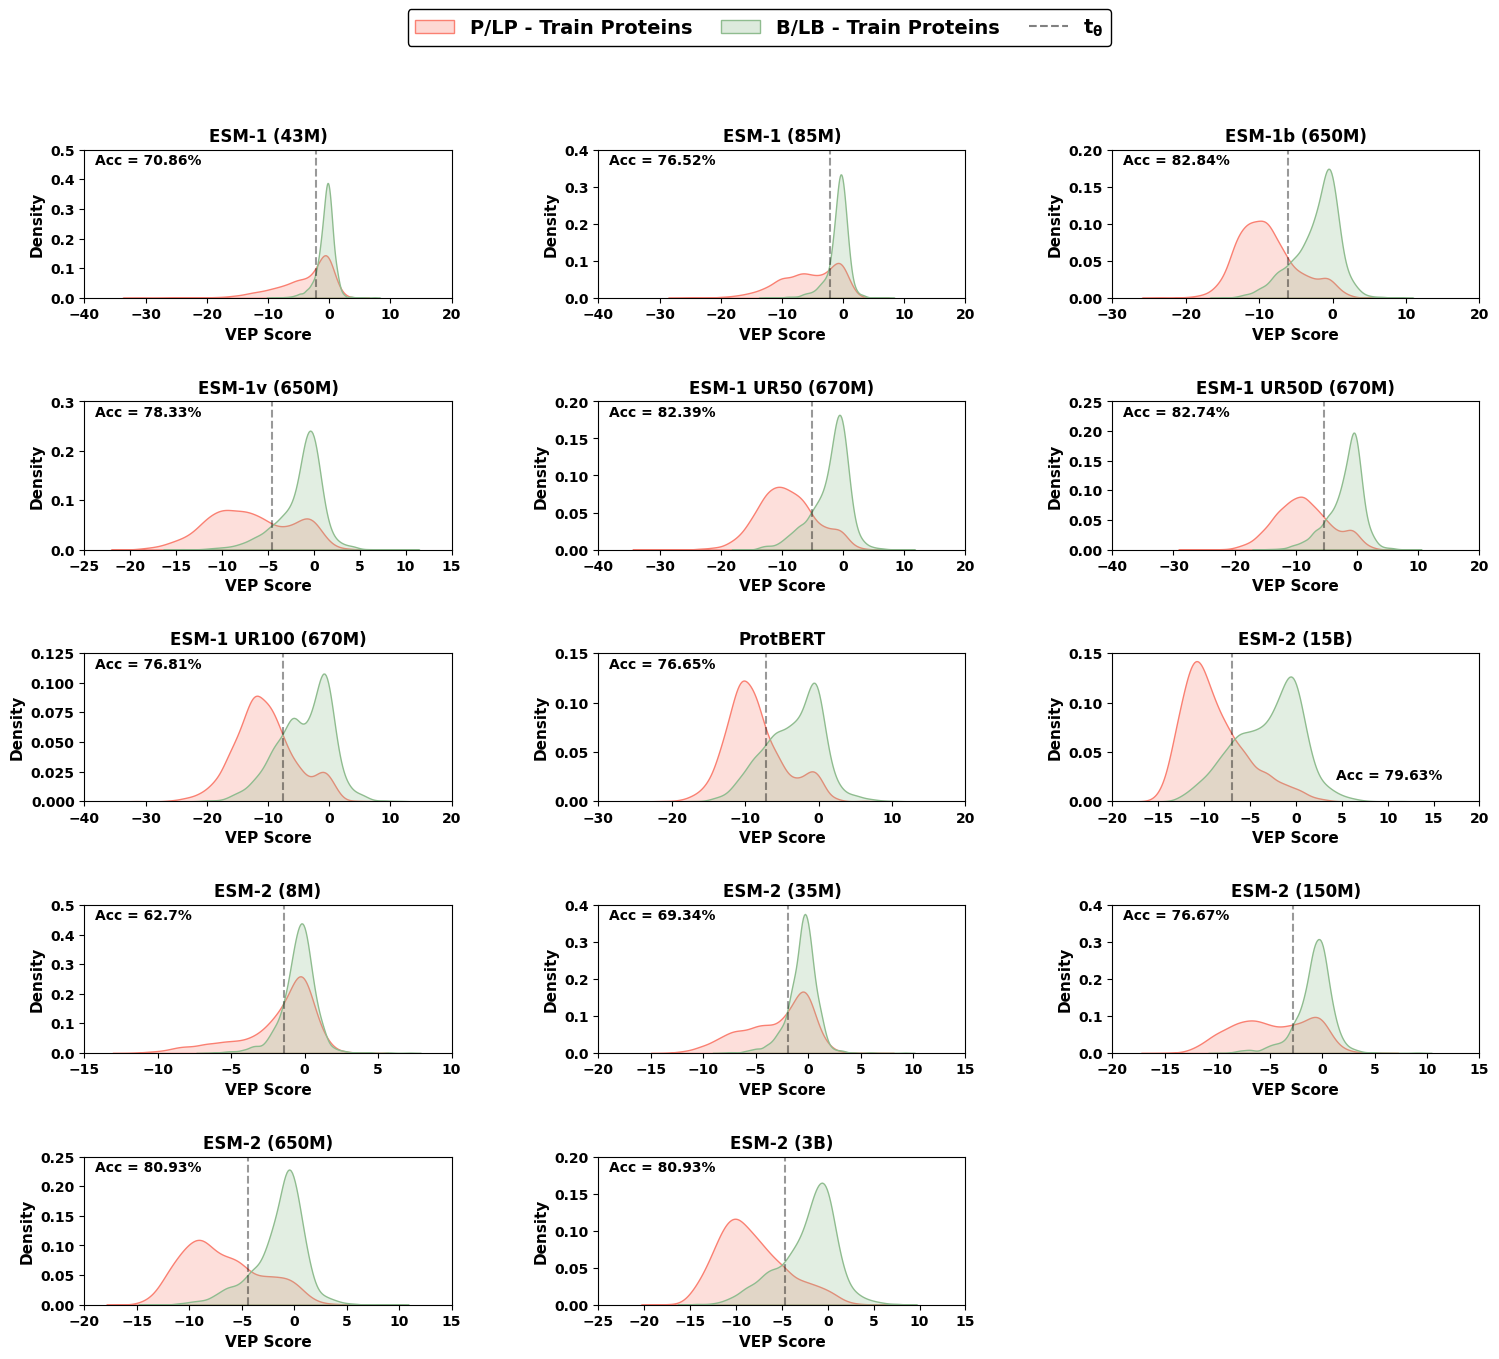

In [109]:
density_fig_large

In [63]:

# removing esm-2 plots, this data is included with boxplots part of the other figure also with rotary based scores
boxplot_fig_large.delaxes(axes_boxplot[-1])
boxplot_fig_large.delaxes(axes_boxplot[-2])
boxplot_fig_large.delaxes(axes_boxplot[-3])
boxplot_fig_large.delaxes(axes_boxplot[-4])
boxplot_fig_large.delaxes(axes_boxplot[-5])
boxplot_fig_large.delaxes(axes_boxplot[-6])
boxplot_fig_large.delaxes(axes_boxplot[-7])
boxplot_fig_large.delaxes(axes_boxplot[-8])

save_figure(boxplot_fig_large, "b_lb_plp_boxplots_all_models", save_svg = True)

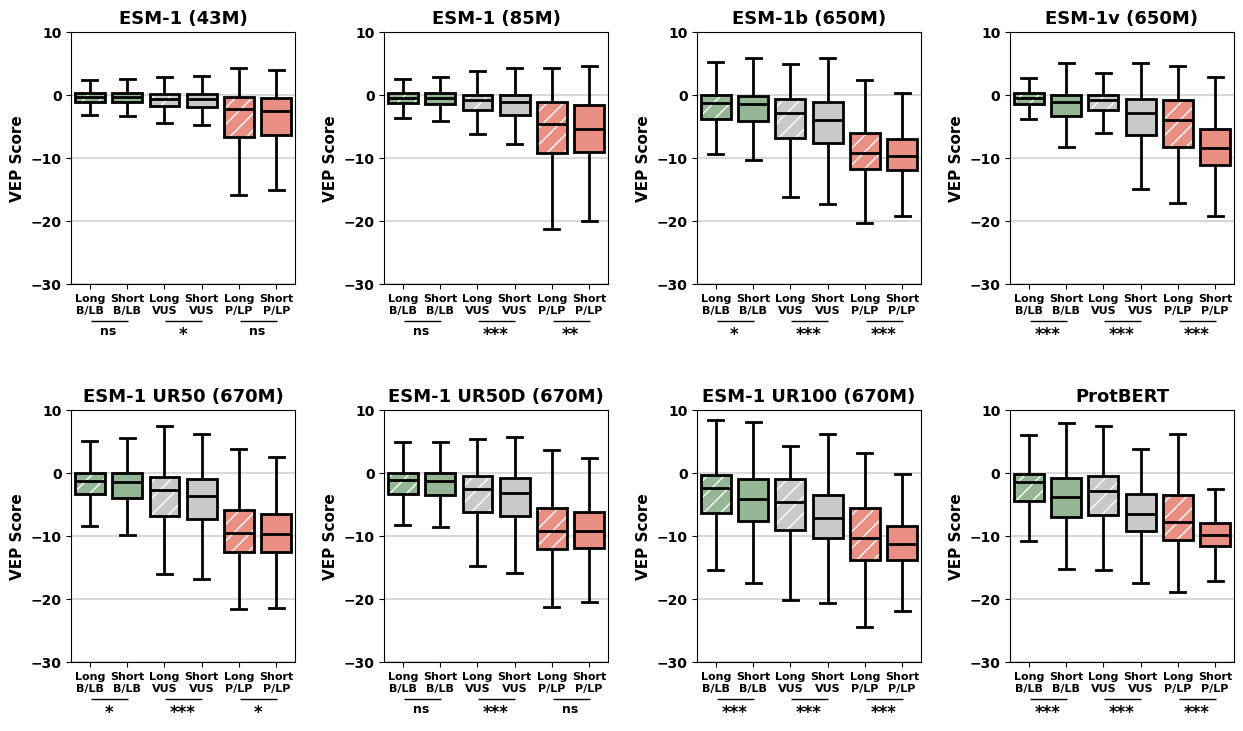

In [64]:
boxplot_fig_large

0.006152490790758433
0.0001095221576982788
0.0013282448152871628
9.83250131419031e-06
3.962234816487361e-11
1.7099089638531815e-09
6.69749620199158e-07
0.004611942065224162
2.5759807649863837e-65
3.4799703764031514e-52
3.8589009787879825e-14


/tmp/ipykernel_2467375/1791541323.py:107: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch0 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 0.8, label='Short Protein P/LP')
/tmp/ipykernel_2467375/1791541323.py:110: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch1 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 0.8, label='Long Protein P/LP')


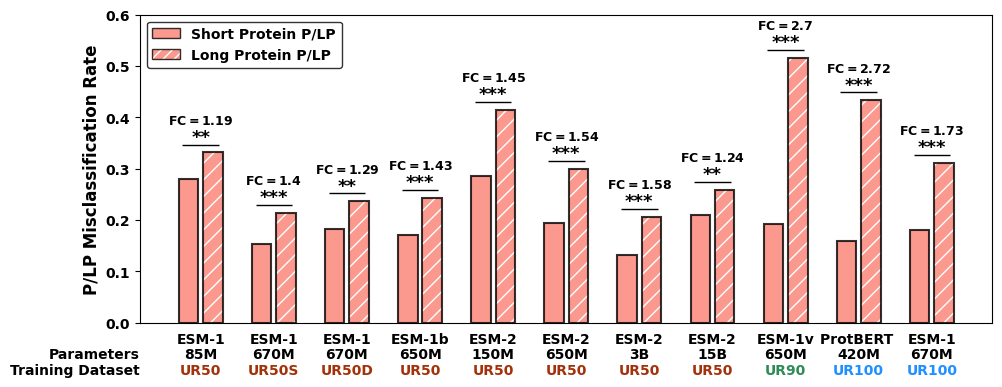

In [42]:

y = []
x = []
i = 0

needed_models = ["esm_1_85M", "esm_1_UR50", "esm_1_UR50D", "esm_1b","esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B", "esm_1v", "protbert",  "esm_1_UR100"]

model_info = pd.read_csv("model_info.txt", delimiter = "\t")


model_to_dataset_string = dict(zip(model_info["model_string"], model_info["dataset_string"]))
model_to_params_string = dict(zip(model_info["model_string"], model_info["params_string"]))
model_to_base_string = dict(zip(model_info["model_string"], model_info["base_string"]))

model_to_dataset_string["esm_1_UR50"] = "UR50S"
model_to_dataset_string["esm_1_UR50D"] = "UR50D"
model_to_dataset_string["esm_1_43M"] = "UR50"
model_to_dataset_string["esm_1_85M"] = "UR50"


model_to_params_string["esm_1_UR50"] = "670M"
model_to_params_string["esm_1_UR50D"] = "670M"
model_to_params_string["esm_1_43M"] = "43M"
model_to_params_string["esm_1_85M"] = "85M"

model_to_base_string["esm_1_UR50"] = 'ESM-1'
model_to_base_string["esm_1_UR50D"] = 'ESM-1'
model_to_base_string["esm_1_43M"] = 'ESM-1'
model_to_base_string["esm_1_85M"] = 'ESM-1'


p_list = []
name_list = []

y_bar_pos_list = []
fc_list = []

star_list = []

for model in needed_models:
    info = model_to_misclass_info[model]
    plp_table = info["PLP_table"]
    acc = info["accuracy_train"]
    misclass_rate_long = plp_table[0][1] / np.sum(plp_table[0])
    misclass_rate_short = plp_table[1][1] / np.sum(plp_table[1])
    fc_plp = misclass_rate_long / misclass_rate_short
    x.append(i)
    y.append(misclass_rate_short)
    i += 1
    x.append(i)
    y.append(misclass_rate_long)
    i += 1

    i+=1
    p_list.append(format_p(info["chi_2_PLP"]))
    name_list.append(model_to_display[model])
    
    y_bar_pos_list.append(misclass_rate_long + 0.015)
    fc_list.append(fc_plp)
    print(info["chi_2_PLP"])
    
    star_list.append(p_val_to_stars(info["chi_2_PLP"]))
    
    


fig, ax = plt.subplots(figsize = (11,4))
ax.bar(x,y, color = "salmon", edgecolor = "black", alpha = 0.8, linewidth = 1.5, zorder = 100)
ax.set_ylim(bottom = 0)

hatch_list = ["", "//"] * len(needed_models)
patches = ax.patches
for patch, hatch in zip(patches, hatch_list):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba("white")

ax.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False
) 



for i , val in enumerate(np.arange(0.5,(3*len(needed_models)),3)):
    ax.text(val , -0.04, model_to_base_string[needed_models[i]], horizontalalignment = "center", fontweight = "bold")
    ax.text(val , -0.1, model_to_dataset_string[needed_models[i]], horizontalalignment = "center", fontweight = "bold", color = dataset_to_color[model_to_dataset_string[needed_models[i]]])
    ax.text(val , -0.07, model_to_params_string[needed_models[i]], horizontalalignment = "center", fontweight = "bold")
    rect = mpatches.Rectangle((val-0.75, y_bar_pos_list[i]), 1.5, 0.0005, clip_on = False, color = "black")
    ax.add_patch(rect)
    ax.text(val, y_bar_pos_list[i] + 0.005, star_list[i], fontweight = "bold", horizontalalignment = "center", fontsize = 13)
    ax.text(val, y_bar_pos_list[i] + 0.04, "$\mathbf{FC=" + str(round(fc_list[i], 2)) + "}$", fontweight = "bold", horizontalalignment = "center",  fontsize = 9)
    
    
ax.text(-2, -0.1, "Training Dataset", horizontalalignment="right", fontweight = "bold")
ax.text(-2, -0.07, "Parameters", horizontalalignment="right", fontweight = "bold")
ax.set_ylabel("P/LP Misclassification Rate", fontsize = 12, fontweight = "bold")
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6])
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")


# for y_val in ax.get_yticks():
#     ax.axhline(y = y_val, color = "black", alpha = 0.2, zorder = 1)


patch0 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 0.8, label='Short Protein P/LP')
patch0.set_edgecolor("black")

patch1 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 0.8, label='Long Protein P/LP')
patch1.set_hatch("///")
patch1.set_edgecolor("black")
patch1._hatch_color = mcolors.to_rgba("white")
plt.legend(handles=[patch0, patch1], loc = "upper left", prop = {"weight" : "bold"}, edgecolor = "black")
# 
save_figure(fig, "plp_misclassification_rates", save_svg = True)

/tmp/ipykernel_2467375/2095121523.py:81: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch0 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Short Protein B/LB')
/tmp/ipykernel_2467375/2095121523.py:84: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch1 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein B/LB')


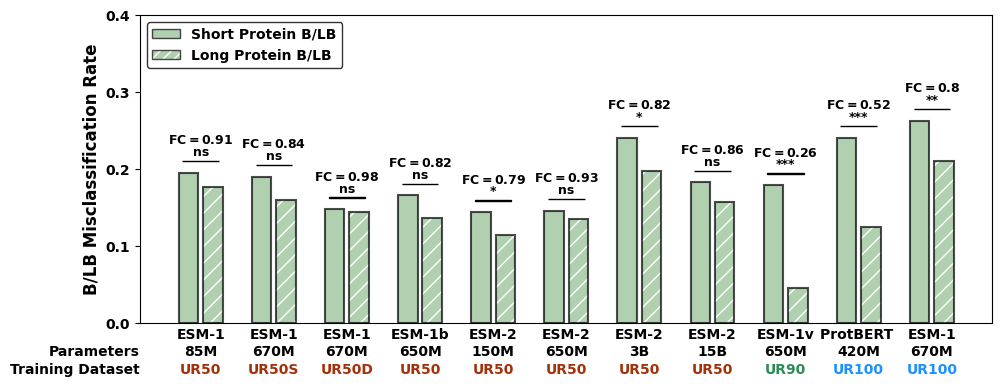

In [32]:
y = []
x = []
i = 0

needed_models = ["esm_1_85M", "esm_1_UR50", "esm_1_UR50D", "esm_1b","esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B", "esm_1v", "protbert",  "esm_1_UR100"]

model_info = pd.read_csv("model_info.txt", delimiter = "\t")


p_list = []
name_list = []

y_bar_pos_list = []
fc_list = []

star_list = []

for model in needed_models:
    info = model_to_misclass_info[model]
    blb_table = info["BLB_table"]
    acc = info["accuracy_train"]
    misclass_rate_long = blb_table[0][1] / np.sum(blb_table[0])
    misclass_rate_short = blb_table[1][1] / np.sum(blb_table[1])
    fc_blb = misclass_rate_long / misclass_rate_short
    x.append(i)
    y.append(misclass_rate_short)
    i += 1
    x.append(i)
    y.append(misclass_rate_long)
    i += 1

    i+=1
    p_list.append(format_p(info["chi_2_BLB"]))
    name_list.append(model_to_display[model])
    
    y_bar_pos_list.append(misclass_rate_short + 0.015)
    fc_list.append(fc_blb)
    
    star_list.append(p_val_to_stars(info["chi_2_BLB"]))
    
    


fig, ax = plt.subplots(figsize = (11,4))
ax.bar(x,y, color = "darkseagreen", edgecolor = "black", alpha = 0.7, linewidth = 1.5)
ax.set_ylim(bottom = 0)

hatch_list = ["", "//"] * len(needed_models)
patches = ax.patches
for patch, hatch in zip(patches, hatch_list):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba("white")

ax.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False
) 



for i , val in enumerate(np.arange(0.5,(3*len(needed_models)),3)):
    ax.text(val , -0.02, model_to_base_string[needed_models[i]], horizontalalignment = "center", fontweight = "bold")
    ax.text(val , -0.065, model_to_dataset_string[needed_models[i]], fontweight = "bold", horizontalalignment = "center", color = dataset_to_color[model_to_dataset_string[needed_models[i]]])
    ax.text(val , -0.0425, model_to_params_string[needed_models[i]], fontweight = "bold", horizontalalignment = "center")
    rect = mpatches.Rectangle((val-0.75, y_bar_pos_list[i]), 1.5, 0.0005, clip_on = False, color = "black")
    ax.add_patch(rect)
    ax.text(val, y_bar_pos_list[i] + 0.0075, star_list[i], fontweight = "bold", horizontalalignment = "center", fontsize = 9)
    ax.text(val, y_bar_pos_list[i] + 0.023, "$\mathbf{FC=" + str(round(fc_list[i], 2)) + "}$", fontweight = "bold", horizontalalignment = "center",  fontsize = 9)
    
    
ax.text(-2, -0.065, "Training Dataset",fontweight = "bold",  horizontalalignment="right")
ax.text(-2, -0.0425, "Parameters",fontweight = "bold",  horizontalalignment="right")
ax.set_ylabel("B/LB Misclassification Rate",fontweight = "bold", fontsize = 12)
ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")


patch0 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Short Protein B/LB')
patch0.set_edgecolor("black")

patch1 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein B/LB')
patch1.set_hatch("///")
patch1.set_edgecolor("black")
patch1._hatch_color = mcolors.to_rgba("white")
plt.legend(handles=[patch0, patch1], loc = "upper left", prop = {"weight" : "bold"}, edgecolor = "black")
# .get_frame().set_edgecolor('red')
save_figure(fig, "blb_misclassification_rates", )

/tmp/ipykernel_2467375/4033805796.py:81: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch0 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Short Protein')
/tmp/ipykernel_2467375/4033805796.py:85: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch1 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein')


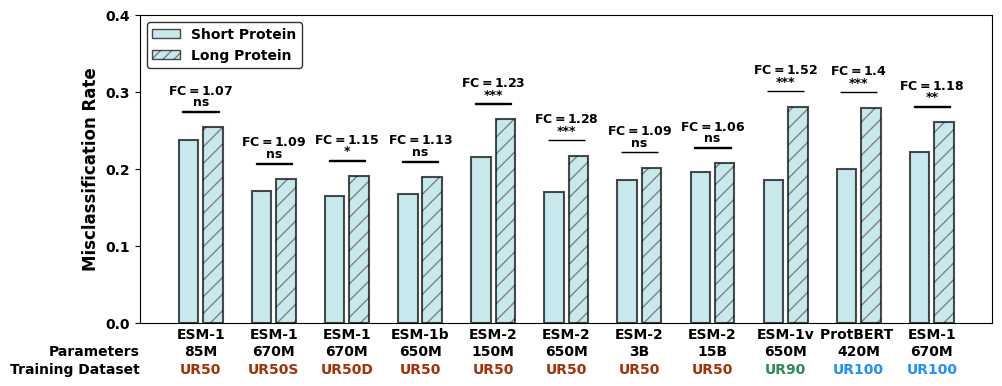

In [45]:
y = []
x = []
i = 0

needed_models = ["esm_1_85M", "esm_1_UR50", "esm_1_UR50D", "esm_1b","esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B", "esm_1v", "protbert",  "esm_1_UR100"]

model_info = pd.read_csv("model_info.txt", delimiter = "\t")


p_list = []
name_list = []

y_bar_pos_list = []
fc_list = []

star_list = []

for model in needed_models:
    info = model_to_misclass_info[model]
    combined_table = info["combined_table"]
    acc = info["accuracy_train"]
    misclass_rate_long = combined_table[0][1] / np.sum(combined_table[0])
    misclass_rate_short = combined_table[1][1] / np.sum(combined_table[1])
    fc_combined = misclass_rate_long / misclass_rate_short
    x.append(i)
    y.append(misclass_rate_short)
    i += 1
    x.append(i)
    y.append(misclass_rate_long)
    i += 1
#     x.append(i)
#     y.append(-0.02)
    i+=1
    p_list.append(format_p(info["chi_2_combined"]))
    name_list.append(model_to_display[model])
    
    y_bar_pos_list.append(misclass_rate_long + 0.02)
    fc_list.append(fc_combined)
    
    star_list.append(p_val_to_stars(info["chi_2_combined"]))
    
    


fig, ax = plt.subplots(figsize = (11,4))
ax.bar(x,y, color = "powderblue", edgecolor = "black", alpha = 0.7, linewidth = 1.5)
ax.set_ylim(bottom = 0)

hatch_list = ["", "//"] * len(needed_models)
patches = ax.patches
for patch, hatch in zip(patches, hatch_list):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba("gray")
#     patch. = "black"
ax.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False
) 



for i , val in enumerate(np.arange(0.5,(3*len(needed_models)),3)):
    ax.text(val , -0.02, model_to_base_string[needed_models[i]], horizontalalignment = "center", fontweight = "bold")
    ax.text(val , -0.065, model_to_dataset_string[needed_models[i]], horizontalalignment = "center",  fontweight = "bold",color = dataset_to_color[model_to_dataset_string[needed_models[i]]])
    ax.text(val , -0.0425, model_to_params_string[needed_models[i]], horizontalalignment = "center", fontweight = "bold")
    rect = mpatches.Rectangle((val-0.75, y_bar_pos_list[i]), 1.5, 0.0005, clip_on = False, color = "black")
    ax.add_patch(rect)
    ax.text(val, y_bar_pos_list[i] + 0.0075, star_list[i], horizontalalignment = "center", fontsize = 9, fontweight = "bold")
    ax.text(val, y_bar_pos_list[i] + 0.023, "$\mathbf{FC=" + str(round(fc_list[i], 2)) + "}$", horizontalalignment = "center",  fontsize = 9, fontweight = "bold")
    
    
ax.text(-2, -0.065, "Training Dataset", horizontalalignment="right", fontweight = "bold")
ax.text(-2, -0.0425, "Parameters", horizontalalignment="right", fontweight = "bold")
ax.set_ylabel("Misclassification Rate", fontsize = 12,fontweight = "bold")
ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")

patch0 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Short Protein')
patch0.set_edgecolor("black")
patch0._hatch_color = mcolors.to_rgba("gray")

patch1 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein')
patch1.set_hatch("///")
patch1.set_edgecolor("black")
patch1._hatch_color = mcolors.to_rgba("gray")
plt.legend(handles=[patch0, patch1], loc = "upper left", prop = {"weight" : "bold"}, edgecolor = "black")